# Exercise 12 – Feature engineering 

**General Instructions:**

- Review the weekly course material (lectures, readings, slides, etc.) before starting the exercises.
- Complete all assigned exercises independently before the Q&A session.
- Please use Julia Version 1.10.x to ensure compatibility.
- Please only write between the `#--- YOUR CODE STARTS HERE ---#` and `#--- YOUR CODE ENDS HERE ---#` comments.

In [5]:
using LinearAlgebra
using Plots
using HDF5
using MAT
using Flux
using Serialization
using Random
using Statistics
using MLUtils  # DataLoader now lives here

## Task 1 – Extended Dynamic Mode Decomposition using a dictionary
Learn a linear dynamical system from trajectory data via the Dynamic Mode Decomposition. As the example, we will use the Duffing oscillator with a two-dimensional state $x\in\mathbb{R}^2$. The function for the right-hand side is given below

In [2]:
function rhs(x)
    ɑ, β, δ = -1, 1, 0.1
    xdot = [x[2], - δ * x[2] - ɑ * x[1] - β * x[1]^3]
    return xdot
end

rhs (generic function with 1 method)

a) Create training data $X$ and $X’$. To this end, draw $N=1000$ initial conditions randomly and uniformly from the rectangle $[-2,2] \times [-2,2]$ and perform one time step using the explicit Euler scheme with a time step of $h = 0.1$. 

In [3]:
X = nothing
X_prime = nothing

### BEGIN SOLUTION

N = 1000
x_range = (-2, 2)

function explicit_euler(x)
    h = 0.1
    return x + h * rhs(x)
end

X = zeros(2, N)
X_prime = zeros(2, N)

#Random.seed!(0)  # for reproducibility
for i = 1:N
    X[:, i] = rand(2) * (x_range[2] - x_range[1]) + [x_range[1], x_range[1]]
    X_prime[:, i] = explicit_euler(X[:, i])
end

### END SOLUTION

In [4]:
@assert size(X) == (2, 1000)
@assert size(X_prime) == (2, 1000)

### BEGIN HIDDEN TESTS

#Check if sample points are in range
for value in X
    @assert value >= -2 && value <= 2
end

#Check if X_prime is calculated correctly
for i in 1:1000
    @assert isapprox(X_prime[:, i], X[:, i] + 0.1 * rhs(X[:, i]))
end
### END HIDDEN TESTS

b) Use DMD in its standard form to learn a linear system with $A\in\mathbb{R}^{2\times 2}$. Simulate the dynamics over $m=100$ time steps using the initial condition $x_0=[1.0, -1.0]$. Report on the RMSE between the created trajectory and a true trajectory of the system (same initial condition, explicit Euler integration).

Note: To avoid confusion regarding the RMSE on multiple dimensions, take this one:
$ \text{RMSE} = \sqrt{ \frac{1}{T} \sum_{t = 1}^{T} \sum_{i = 1}^{d} (X_{t, i} - Y_{t, i})^2 } $

In [5]:
x0 = [1.0, -1.0]

A = nothing
dmd_trajectory = nothing
euler_trajectory = nothing
RMSE = nothing

### BEGIN SOLUTION

function dynamic_mode_decomposition(X, X_prime)
    # Solve the least squares problem X' = AX
    A = X_prime / X
    return A
end

# Function to simulate the dynamics using matrix A
function simulate_dynamics(A, x0, m)
    states = [x0]
    for i = 1:m-1
        push!(states, A * states[end])
    end
    return hcat(states...)
end

# Function to compute RMSE
function rmse(euler_trajectory, dmd_trajectory)
    return sqrt(mean(sum((euler_trajectory .- dmd_trajectory) .^ 2, dims=1)))
end

# Main execution
A = dynamic_mode_decomposition(X, X_prime)  # Compute DMD matrix A
x0 = [1.0, -1.0]  # Example initial condition, replace with actual values
m = 100  # Number of time steps

# Simulate dynamics
dmd_trajectory = simulate_dynamics(A, x0, m)

# Generate true trajectory (using euler_step function from part a)
euler_trajectory = [x0]
for i = 1:m-1
    push!(euler_trajectory, explicit_euler(euler_trajectory[end]))
end
euler_trajectory = hcat(euler_trajectory...)

# Compute RMSE error
RMSE = rmse(euler_trajectory, dmd_trajectory)
println("RMSE: ", RMSE)

### END SOLUTION


RMSE: 2.1100058656068406


c) Implement a dictionary of radial basis functions (RBFs), i.e.,  
$$ 
\varphi_c(x) = \exp(- \gamma \| x - c \|_2^2 ),
$$ 
$$ 
z = \Psi(x) = [\varphi_{c_1}(x), \ldots, \varphi_{c_r}(x)],
$$ 
where the $c_i\in\mathbb{R}^2$ are the centers of the individual RBFs and $\gamma>0$ is a hyperparameter determining the width of the RBF 

In [6]:
# Function to compute the lifted state using a dictionary of RBFs
function rbf_dictionary(x, centers, gamma=1.5)
    ### BEGIN SOLUTION
    return [exp(-gamma * norm(x - center)^2) for center in centers]
    ### END SOLUTION
end

rbf_dictionary (generic function with 2 methods)

In [7]:
@assert isa(rbf_dictionary, Function)
@assert length(rbf_dictionary([1, 1], [[2, 2], [3, 3]])) == 2
@assert length(rbf_dictionary([1, 1], [[2, 2], [3, 3], [4, 4]])) == 3

### BEGIN HIDDEN TESTS
@assert isapprox(rbf_dictionary([1, 1], [[2, 2], [3, 3]]), [0.049787068367863896, 6.144212353328188e-6])
@assert isapprox(rbf_dictionary([0, 0], [[2, 2], [2, -2], [-2, 2], [-2, -2]]), [6.144212353328188e-6, 6.144212353328188e-6, 6.144212353328188e-6, 6.144212353328188e-6])
### END HIDDEN TESTS

d) Use the extended version of DMD (aka EDMD), where you find a linear system for the lifted state $\Psi(x)=z\in\mathbb{R}^r$ instead of $x\in\mathbb{R}^2$ (use the trajectory from a) ). To this end, introduce $r=100$ centers on an equidistant $10 \times 10$ grid in the area $[-2, 2] \times [-2, 2]$, with $\gamma = 1$. Train the corresponding matrix $A\in\mathbb{R}^{100 \times 100}$. 

In [8]:
centers = nothing
Z = nothing
Z_prime = nothing
A_edmd = nothing

### BEGIN SOLUTION

# Example usage
num_centers = 100  # Number of RBF centers
grid_size = round(Int, sqrt(num_centers))  # Convert to integer, assuming a square grid for centers

# Generate centers for RBFs on a grid
# old: centers = [[i, j] for i in x_range[1]:abs(x_range[1] - x_range[2])/(grid_size-1):x_range[2] for j in x_range[1]:abs(x_range[1] - x_range[2])/(grid_size-1):x_range[2]]
p = range(-2, 2, length=grid_size)
centers = [[x, y] for x in p for y in p]

# Function to compute lifted states for all training data
function compute_lifted_states(X, centers)
    return [rbf_dictionary(X[:, i], centers) for i = 1:size(X, 2)]
end

# Main execution for EDMD

# Compute lifted states for X and X'
Z = hcat(compute_lifted_states(X, centers)...)
Z_prime = hcat(compute_lifted_states(X_prime, centers)...)

A_edmd = dynamic_mode_decomposition(Z, Z_prime)

### END SOLUTION

100×100 Matrix{Float64}:
 -0.491936   -1.2738      2.22652   -2.59001   …   0.0441197  -0.0300324
  3.42859    -6.24117     5.21445   -4.14524      -0.100049    0.0304172
  2.06031    -0.380009   -1.37014    0.247168     -0.0889387   0.0277495
 -0.114923    1.35679     1.62143   -3.82272       0.0212694  -0.0138224
 -0.593279    1.27376    -0.705973   4.41543       0.723824   -0.278466
 -0.606447    1.52839    -2.48661    4.12072   …   0.343946   -0.134779
  0.951442   -2.68151     4.91887   -7.50427      -1.11326     0.451387
  0.34246    -0.980009    1.72024   -2.28945      -2.22255     0.900687
 -0.429918    1.12579    -1.92997    2.74648      -1.22285     0.476555
 -0.765754    2.05065    -3.5839     5.20115       1.59534    -0.495704
  ⋮                                            ⋱              
  0.952417   -2.14995     3.43983   -3.8717       -1.11154     0.413423
  0.967182   -2.19383     2.9081    -2.43226      -0.431189    0.17696
 -0.110423    0.394066   -0.881654   1.4123  

e) Implement a projection operation that maps from $z$ to $x$, such that you can reconstruct the original state $x$ from predictions of the lifted state $z$. This step can be realized by a linear mapping $x = P z$, where the projection matrix $P\in\mathbb{R}^{2\times r}$ can be determined using linear regression. 

In [9]:
P = nothing

### BEGIN SOLUTION
P = X / Z # Linear regression to find P
### END SOLUTION

2×100 Matrix{Float64}:
 -3.06036    0.709365  -1.39788   -2.54423   …  5.78571  -3.52066  4.27426
 -0.902047  -1.28563    0.203719   0.239314     2.78133  -1.67056  2.76282

In [10]:
@assert size(P) == (2, 100)

### BEGIN HIDDEN TESTS
@assert isapprox(X, P * Z, atol=0.5)
### END HIDDEN TESTS

f) Repeat the experiment from b), but now compare the original trajectory to the one obtained using EDMD and the consecutive projection step to recover $x$. 

```Hint: Don't forget to transform the initial condition accordingly```

In [11]:
edmd_trajectory_lifted = nothing
edmd_trajectory_projected = nothing
error_edmd = nothing

### BEGIN SOLUTION

# Function to simulate dynamics using the EDMD matrix A
function simulate_edmd_dynamics(A, z0, m)
    lifted_states = [z0]
    for i = 1:m-1
        push!(lifted_states, A * lifted_states[end])
    end
    return hcat(lifted_states...)
end

# Function to project the lifted state trajectory back to the original state space
function project_trajectory(P, lifted_trajectory)
    return P * lifted_trajectory
end

# Main execution for simulating and projecting EDMD dynamics
z0 = rbf_dictionary(x0, centers)  # Lifted initial condition
m = 100  # Number of time steps

# Simulate EDMD dynamics
edmd_trajectory_lifted = simulate_edmd_dynamics(A_edmd, z0, m)

# Project the lifted state trajectory back to the original state space
edmd_trajectory_projected = project_trajectory(P, edmd_trajectory_lifted)

# Compute RMSE between projected EDMD trajectory and true trajectory
error_edmd = rmse(euler_trajectory, edmd_trajectory_projected)
println("RMSE (EDMD): ", error_edmd)

### END SOLUTION

RMSE (EDMD): 1.2015339346417029


## Task 2 – Comparing SVD and Autoencoders
In this exercise, we want to compare the capabilities of the Singular Value Decomposition (SVD) and an autoencoder in terms of data compression of high-dimensional trajectory data. The following data set $X\in\mathbb{R}^{101 \times 6001}$ has been created by simulating the Burgers PDE (https://en.wikipedia.org/wiki/Burgers%27_equation) on an $n = 101$-dimensional spatial grid for $N=6000$ time steps. 

a) Use the SVD to compress the $n$-dimensional state into a much lower dimension $k\ll n$. Select the smallest value for $k$ for which the reconstruction error between the original data $x$ and the reconstructed data $\tilde{x}$ is less than 0.1%, i.e. 
$$ 
\frac{ \sum_{i=1}^N \|x_i – \tilde{x}_i \|_2^2 }{ \sum_{i=1}^N \|x_i \|_2^2 } < 0.001. 
$$ 

In [6]:
#Data loading
file = matopen("burgers.mat")
X = read(file, "u")
close(file)

In [7]:
function loss_function(original, reconstructed)
    ### BEGIN SOLUTION
    return sum((original - reconstructed) .^ 2) / sum(original .^ 2)
    sum((autoencoder(x) .- x).^2) / length(x)
    ### END SOLUTION
end

loss_function (generic function with 1 method)

In [8]:
@assert isa(loss_function, Function)

### BEGIN HIDDEN TESTS
@assert isapprox(0.0035087719298245615, loss_function([1 2 3; 4 5 6; 7 8 9], [1 2 3; 4 5 6; 7 8 10]))
### END HIDDEN TESTS

In [9]:
k = nothing
X_reconstructed_k = nothing

### BEGIN SOLUTION

U, S, V = svd(X)
#display(Plots.plot(S, seriestype=:scatter, yscale=:log10))

# Choose number of singular values to keep
k = 6

# Create a reduced version of the matrix S
S_k = Diagonal(S[1:k])

# Create reduced versions of matrices U and V
U_k = U[:, 1:k]
V_k = V[:, 1:k]

# Reconstruct the data with the reduced matrices
X_reconstructed_k = U_k * S_k * V_k'

#error calculation
println(loss_function(X, X_reconstructed_k))

### END SOLUTION

0.0006873083689810761


Original Image
Reconstructed Image


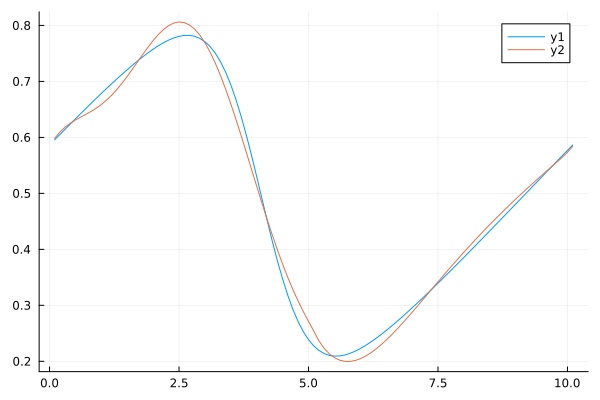

In [10]:
#Random SVD sample comparison
random_index = rand(1:size(X,2))
x = range(0.1,10.1, length = 101)
println("Original Image")
Plots.plot(x,X[:, random_index])
println("Reconstructed Image")
display(Plots.plot!(x,X_reconstructed_k[:, random_index]))

b) Now compare this to an autoencoder architecture of your choice. The only constraints that should be respected are: 
- Use only fully connected feed-forward layers (i.e., no convolutions) 
- the bottleneck layer connecting the encoder and the decoder (i.e., the smallest layer whose latent state is the compressed state) has to have dimension at most $r=5$. 
This task is fulfilled if your trained architecture can satisfy the error criterion from a) 

In [11]:
#define your autoencoder
autoencoder = nothing

### BEGIN SOLUTION
X = Float32.(reshape(X, 101, :))

# Define the layer sizes
originalSize = 101
hiddenSize_1 = 50
bottleneck = 5

# Define autoencoder architecture
encoder = Chain(
    Dense(originalSize, hiddenSize_1, relu),
    Dense(hiddenSize_1, bottleneck, relu),)
decoder = Chain(
    Dense(bottleneck, hiddenSize_1, relu),
    Dense(hiddenSize_1, originalSize, σ)
)
autoencoder = Chain(encoder, decoder)

#Training parameters
function loss_function(auto, orig)
    return sum((auto .- orig).^2) / size(orig, 2)
end

loss(m,x) = loss_function(m(x), x)
opt = ADAM(0.001)
data = DataLoader(X, batchsize=64, shuffle=true)
total_training_it = 0

### END SOLUTION


0

In [12]:
@assert isa(autoencoder, Flux.Chain)

In [15]:
# Train your autoencoder.

### BEGIN SOLUTION

epochs = 200
loss_value = 0
total_training_it = 0
opt_state = Flux.setup(opt, autoencoder)
for epoch in 1:epochs
    total_training_it += 1
    for d in data
        # Compute loss and gradients
        batch_loss, grads = Flux.withgradient(autoencoder) do m
            loss(m,d)
        end
        # Update parameters
        Flux.update!(opt_state, autoencoder, grads[1])
    end
    loss_value = loss(autoencoder,X)
    if epoch % 50 == 0
        println("Epoch: $total_training_it, Loss: $loss_value")
    end
end

### END SOLUTION

Epoch: 50, Loss: 0.0006046016
Epoch: 100, Loss: 0.0003681707
Epoch: 150, Loss: 0.00031416854
Epoch: 200, Loss: 0.00028473165


In [18]:
#Make sure that the model is not overwritten during autograding
if @isdefined autoencoder
    #Save your model as file
    @assert isa(autoencoder, Flux.Chain)
    serialize("autoencoder", autoencoder)
end

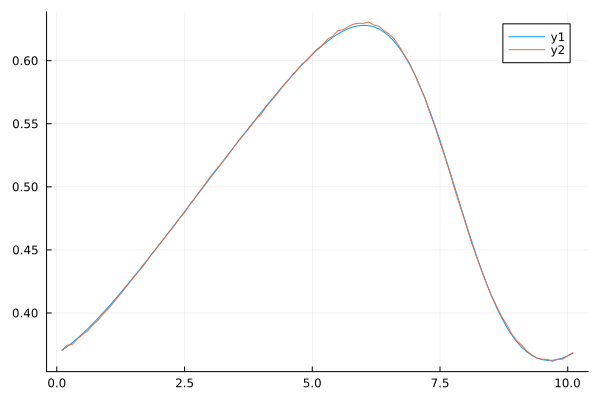

In [16]:
#Random autoencoder sample comparison
x = range(0.1,10.1, length = 101)
random_index = rand(1:size(X,2))
original = X[:,random_index]
reconstruction = autoencoder(original)
Plots.plot(x,original)
display(Plots.plot!(x,reconstruction))